# 8.4 总结：生成式召回、排序与召排融合

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

读取本章节每个独立算法 Notebook 的实际结果产物，在统一口径下比较和选型。

## Setup

本 Notebook 的默认真实数据是 **KuaiRand-Pure：真实短视频曝光、点击、长播与多反馈序列**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。 **生成式章节默认要求 CUDA；无 CUDA 时只允许自动化测试执行 CPU basic smoke，不进行完整精度验证。**

**主要资料：** TIGER · OpenOneRec · HSTU 论文及官方仓库

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "kuairand"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'kuairand', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 开篇回顾

本章节固定为 **开篇导读 → 独立算法教程 → 结果总结**。每篇算法 Notebook 都包含论文、数学、数据、训练、推理、测试与讨论；本页不重新训练，也不手填数字。

OpenOneRec 关注 Semantic ID、列表解码与奖励对齐；HSTU 关注统一长序列。共同验收维度是相关性、合法性、重复率、目录更新、解码延迟与 GPU ROI。

## 论文关联关系：后一篇在修补前一篇的哪块短板？

三篇论文不是同一赛道上的升级排名，而是把“生成”逐层推深：TIGER 先回答“物品怎么变成可生成的标识”，OneRec 回答“生成能不能统一召回与排序并对齐偏好”，HSTU 回答“整个推荐能不能变成随算力扩展的序列转导”。下表中的“交接问题”比发表年份更重要。

In [2]:
import pandas as pd
paper_relationships = pd.DataFrame([{'paper': 'TIGER (2023)', 'starts_from': 'embedding+ANN 检索无法利用物品的层次语义，随机 ID 对新物品无泛化', 'user_representation': '用户历史 = Semantic ID token 序列；物品 = RQ-VAE 多级码，相似物品共享前缀', 'training_signal': 'seq2seq 对下一物品 Semantic ID 的逐 token 交叉熵（teacher forcing）', 'serving_shape': '自回归解码 + 目录约束，替代 ANN 召回', 'hands_to_next': '只替代召回一级，排序仍靠级联；逐点生成后要靠人工规则拼列表'}, {'paper': 'OneRec / OpenOneRec (2025)', 'starts_from': '级联召排各级独立优化、目标不一致，前级上限即后级天花板', 'user_representation': '256 条历史行为编码 → decoder 自回归生成 5 物品 session', 'training_signal': 'session 级 NTP 交叉熵 + IPA：自采 128 个列表、RM 打分、best/worst 做 DPO（仅 1% 数据）', 'serving_shape': '单模型端到端生成整屏列表；KV cache + beam 128 + 13% MoE 激活', 'hands_to_next': '离线指标由 reward 模型估计而非真实行为；互动指标仍弱；1B 规模与 beam 解码成本高'}, {'paper': 'HSTU (2024)', 'starts_from': 'DLRM 依赖手工特征拼装且不随算力扩展；softmax 归一化抹掉相关历史强度', 'user_representation': '全部特征序列化为统一流，HSTU 层逐位置输出表示', 'training_signal': '生成式 next-item 交叉熵（按 1/n_i 采样用户，成本降一个 O(N) 因子）', 'serving_shape': '长序列统一转导 + M-FALCON 微批推理；285x FLOPs 换 1.50x/2.99x QPS', 'hands_to_next': '依赖 Meta 级流式基础设施与算力；公开集 multi-pass 评测与线上单遍流式口径不同'}])
display(paper_relationships)

,paper,starts_from,user_representation,training_signal,serving_shape,hands_to_next
0,TIGER (2023),embedding+ANN 检索无法利用物品的层次语义，随机 ID 对新物品无泛化,用户历史 = Semantic ID token 序列；物品 = RQ-VAE 多级码，相似...,seq2seq 对下一物品 Semantic ID 的逐 token 交叉熵（teacher...,自回归解码 + 目录约束，替代 ANN 召回,只替代召回一级，排序仍靠级联；逐点生成后要靠人工规则拼列表
1,OneRec / OpenOneRec (2025),级联召排各级独立优化、目标不一致，前级上限即后级天花板,256 条历史行为编码 → decoder 自回归生成 5 物品 session,session 级 NTP 交叉熵 + IPA：自采 128 个列表、RM 打分、best/...,单模型端到端生成整屏列表；KV cache + beam 128 + 13% MoE 激活,离线指标由 reward 模型估计而非真实行为；互动指标仍弱；1B 规模与 beam 解码成本高
2,HSTU (2024),DLRM 依赖手工特征拼装且不随算力扩展；softmax 归一化抹掉相关历史强度,全部特征序列化为统一流，HSTU 层逐位置输出表示,生成式 next-item 交叉熵（按 1/n_i 采样用户，成本降一个 O(N) 因子）,长序列统一转导 + M-FALCON 微批推理；285x FLOPs 换 1.50x/2.9...,依赖 Meta 级流式基础设施与算力；公开集 multi-pass 评测与线上单遍流式口径不同


## Results

读取 results 目录。若缺文件，请先按章节顺序执行算法 Notebook。

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
result_dir=ARTIFACT_ROOT/'results'/'chapter_8'; files=sorted(result_dir.glob('*.json'))
assert len(files)==2,f'期望 2 个结果，实际 {[p.name for p in files]}'
records=[]
for path in files: records.extend(json.loads(path.read_text(encoding='utf-8'))['records'])
comparison=pd.DataFrame(records); display(comparison.round(4)); print('数据来源:',[p.name for p in files])

,algorithm,primary_metric,primary_value,secondary_metric,secondary_value,baseline_metric,baseline_value,framework,source_notebook,validation_mode,dataset,randomly_fabricated_rows
0,OpenOneRec：受约束列表生成实战,invalid_constrained,0.0,invalid_unconstrained,1.0,None,None,OpenOneRec contract + PyTorch executable proxy,8_2_openonerec_practice,cpu_basic_smoke,"KuaiRand-Pure (Kuaishou, CIKM 2022)",0
1,DLRM HSTU：长行为序列实战,hr@5,0.0,popularity_hr@5,0.0,None,None,torch_rechub.models.generative.HSTUModel,8_3_dlrm_hstu_practice,cpu_basic_smoke,"KuaiRand-Pure (Kuaishou, CIKM 2022)",0


数据来源: ['8_2_openonerec_practice.json', '8_3_dlrm_hstu_practice.json']


图表字体: ASCII fallback（宿主机未安装 CJK 字体）


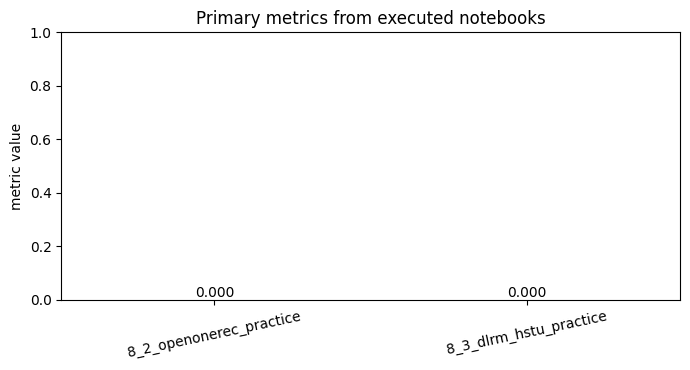

In [4]:
from matplotlib import font_manager

# Matplotlib 默认的 DejaVu Sans 不包含中文字形。优先选择容器中安装的
# Noto CJK；在精简宿主机上找不到中文字体时，退回纯 ASCII 的 Notebook 编号，
# 从根源避免 missing glyph 警告，而不是用 warnings.filterwarnings 隐藏它。
cjk_candidates = ('Noto Sans CJK SC', 'Noto Sans CJK JP', 'Microsoft YaHei', 'SimHei', 'PingFang SC')
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
cjk_font = next((name for name in cjk_candidates if name in installed_fonts), None)
if cjk_font:
    plt.rcParams['font.sans-serif'] = [cjk_font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
chart_labels = comparison.algorithm if cjk_font else comparison.source_notebook
print('图表字体:', cjk_font or 'ASCII fallback（宿主机未安装 CJK 字体）')

fig,ax=plt.subplots(figsize=(max(7,len(comparison)*1.5),3.8))
bars=ax.bar(chart_labels,comparison.primary_value,color='#7ca832')
ax.set(title='Primary metrics from executed notebooks',ylabel='metric value',ylim=(0,max(1.0,comparison.primary_value.max()*1.18)))
ax.tick_params(axis='x',rotation=12)
for bar,value in zip(bars,comparison.primary_value): ax.text(bar.get_x()+bar.get_width()/2,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show()

## 未来发展：沿着什么约束继续前进？

未来路线不是一味堆更深网络，而是逐项解除当前系统约束。表格从左到右给出本章已经走过的变化和仍待验证的方向；最后一列是研究/工程问题，不是预告一定会获得线上提升。

In [5]:
future = pd.DataFrame([['物品表示', 'RQ-VAE 层次 Semantic ID', '均衡 K-Means 残差量化（每层 8192 簇）', '统一特征序列化，无显式 ID', '多模态内容与行为联合、可增量更新的标识'], ['生成单位', '下一物品的 ID token', '整屏 session 列表', '任意未来事件序列', '列表级多样性/新颖性的显式建模'], ['训练信号', '逐 token 交叉熵', 'NTP + 自采样迭代 DPO', '生成式 next-item + 流式采样', '在线反馈闭环、多目标对齐与去偏'], ['服务形态', '受约束自回归解码替代 ANN', '单模型端到端 + beam 128', '统一转导 + M-FALCON 微批', '模型与索引/推理内核联合设计、目录增量更新'], ['必须补测', '非法 ID 率 + 冷启动泛化', '合法率/重复率 + RM 估计偏差', '长序列成本 + 流式口径一致性', 'P99 延迟、GPU ROI、线上因果收益与公平性']], columns=['dimension', 'TIGER line', 'OneRec line', 'HSTU line', 'next questions'])
display(future)

,dimension,TIGER line,OneRec line,HSTU line,next questions
0,物品表示,RQ-VAE 层次 Semantic ID,均衡 K-Means 残差量化（每层 8192 簇）,统一特征序列化，无显式 ID,多模态内容与行为联合、可增量更新的标识
1,生成单位,下一物品的 ID token,整屏 session 列表,任意未来事件序列,列表级多样性/新颖性的显式建模
2,训练信号,逐 token 交叉熵,NTP + 自采样迭代 DPO,生成式 next-item + 流式采样,在线反馈闭环、多目标对齐与去偏
3,服务形态,受约束自回归解码替代 ANN,单模型端到端 + beam 128,统一转导 + M-FALCON 微批,模型与索引/推理内核联合设计、目录增量更新
4,必须补测,非法 ID 率 + 冷启动泛化,合法率/重复率 + RM 估计偏差,长序列成本 + 流式口径一致性,P99 延迟、GPU ROI、线上因果收益与公平性


## Takeaways

OpenOneRec 关注 Semantic ID、列表解码与奖励对齐；HSTU 关注统一长序列。共同验收维度是相关性、合法性、重复率、目录更新、解码延迟与 GPU ROI。

先固定业务阶段和候选口径，再比较主指标、辅助指标、baseline 与系统成本。smoke 数值用于代码回归和学习，不能跨数据或跨公司宣称优劣。

## Checks

In [6]:
assert len(comparison)==2
assert comparison.source_notebook.nunique()==2
assert comparison.primary_value.between(0,1).all()
print('PASS：总结完全来自独立 Notebook 的执行产物。')

PASS：总结完全来自独立 Notebook 的执行产物。


## Next Steps

在相同完整数据、时间切分、负样本和候选集上重跑；加入效果—延迟—成本三维表，再决定是否进入线上 A/B。